# Лекция 1. Асинхронность и конкурентность в Python

## О чём лекция

Представьте: программа делает 10 HTTP-запросов по очереди.
Каждый занимает 1 секунду. Итого 10 секунд. Но процессор простаивает ~9.9 секунд
из 10 — он просто ждёт ответ от сети.

**Проблема не в скорости CPU, а в том, что программа стоит и ждёт.**

В этой лекции разберём:
1. Почему CPU простаивает (I/O-bound vs CPU-bound)
2. Три подхода: `threading`, `multiprocessing`, `asyncio`
3. Когда что применять

---

## 1. Два типа задач

Одни задачи упираются в скорость CPU, другие — в скорость внешних устройств.
От этого зависит, какой инструмент нам поможет.

| Тип | Что происходит | Примеры | CPU |
|-----|---------------|---------|-----|
| **I/O-bound** | Программа **ждёт** внешнее устройство | HTTP-запросы, чтение файлов, SQL-запросы, SNMP-опрос | Свободен |
| **CPU-bound** | Программа **считает** | Обработка изображений, сжатие, парсинг, расчёт BGP-метрик | Занят |

**Аналогия:** повар на кухне. Пока суп варится (I/O), можно резать салат.
Но если нужно перебрать 100 кг гречки (CPU), переключение не поможет —
нужна вторая пара рук.

---

## 2. Что такое конкурентность

**Конкурентность (concurrency)** — выполнение нескольких задач с перекрытием
во времени. Задачи не обязательно выполняются одновременно — но их выполнение
накладывается.

| | Конкурентность | Параллелизм |
|---|---|---|
| Суть | Задачи **выглядят** одновременными | Задачи **реально** выполняются одновременно |
| Сколько ядер нужно | Достаточно 1 ядра | Нужно ≥ 2 ядер |
| Пример в Python | `threading`, `asyncio` | `multiprocessing` |

**Конкурентность — про структуру программы** (как переключаемся между задачами).
**Параллелизм — про исполнение** (сколько задач физически выполняется в момент).

---

## 3. Многопоточность — threading

### Как работает

**Поток (thread)** — линейный путь выполнения кода внутри процесса.
Несколько потоков делят память процесса. ОС может переключить любой поток
в любой момент (вытесняющая многозадачность).

```python
import threading, time

def work(name: str, delay: int) -> None:
    time.sleep(delay)
    print(f"[{name}] done in {delay}s")

t1 = threading.Thread(target=work, args=("A", 3))
t2 = threading.Thread(target=work, args=("B", 2))
t1.start(); t2.start()
t1.join(); t2.join()  # ждём завершения
```

### GIL (Global Interpreter Lock)

GIL — блокировка CPython, разрешающая выполнять **только один поток
байт-кода** одновременно. Это важно:

- **При I/O** (сеть, диск) — GIL **отпускается**, другие потоки работают
- **При CPU-bound** — GIL **не отпускается**, поток блокирует всех

### ThreadPoolExecutor — удобная обёртка

```python
from concurrent.futures import ThreadPoolExecutor, as_completed

with ThreadPoolExecutor(max_workers=10) as pool:
    # dict-to-future: каждый Future → URL/устройство
    future_to_url = {pool.submit(fetch, url): url for url in urls}
    for future in as_completed(future_to_url):  # по мере готовности
        url = future_to_url[future]
        print(f"{url}: {future.result()}")
```

`as_completed()` отдаёт результаты **по мере готовности**, не в порядке запуска.
Быстрые запросы приходят первыми.

---

## 4. Многопроцессорность — multiprocessing

### Зачем

Threading **не ускоряет** CPU-bound задачи из-за GIL. Для этого — процессы:

- У каждого процесса свой интерпретатор Python, своя память, свой GIL
- Процессы выполняются **параллельно** на разных ядрах CPU

In [ ]:
from time import sleep, strftime
from concurrent import futures


def display(*args):
    print(strftime("[%H:%M:%S]"), end=" ")
    print(*args)


def loiter(n):
    msg = "{}loiter({}): doing nothing for {}s..."
    display(msg.format("\t" * n, n, n))
    sleep(n)
    msg = "{}loiter({}): done."
    display(msg.format("\t" * n, n))
    return n * 10


def main():
    display("Script starting.")
    executor = futures.ThreadPoolExecutor(max_workers=3)
    results = executor.map(loiter, range(5))
    display("results:", results)
    display("Waiting for individual results:")
    for i, result in enumerate(results):
        display(f"result {i}: {result}")


if __name__ == "__main__":
    main()

---

## 5. Асинхронность — asyncio

Начнем с исторической справки о том, как в питоне зародилась асинхронность.

In [ ]:
def eager_range(up_to: int) -> list[int]:
    sequence = []
    index = 0
    while index < up_to:
        sequence.append(index)
        index += 1
    return sequence

Цель асинхронности - научиться переключаться между задачами, не потеряв и завершив эти задачи в какой-то момент времени попозже. Простой пример: сделали сетевой запрос, пока ждем ответ хочется делать что-то еще, а не иметь простаивающие ресурсы. Давайте поймем как решили эту задачу в питоне:

In [ ]:
# Начиная с python 2.2 появились генераторы - https://peps.python.org/pep-0255/
from collections.abc import Generator, AsyncGenerator


def lazy_range(up_to: int) -> Generator[int, None, None]:
    index = 0
    while index < up_to:
        yield index
        index += 1

In [ ]:
# python 2.5 - метод send - https://peps.python.org/pep-0342/


def jumping_range(up_to: int) -> Generator[int, int | None, None]:
    index = 0
    while index < up_to:
        jump = yield index
        if jump is None:
            jump = 1
        index += jump

In [ ]:
generator = jumping_range(5)

print("next   :", next(generator))
print("send  2:", generator.send(2))
print("next   :", next(generator))
print("send -1:", generator.send(-1))

In [ ]:
# python 3.3 - yield from - https://peps.python.org/pep-0380/


def bottom() -> Generator[int, None, int]:
    yield 1
    yield 2
    return 3


def top() -> Generator[int, None, None]:
    value = yield from bottom()
    print(value)

In [ ]:
top()

list(top())

In [ ]:
# python 3.4 - asyncio - https://docs.python.org/3/library/asyncio.html
import asyncio
import types
import nest_asyncio

nest_asyncio.apply()

In [ ]:
@types.coroutine  # asyncio.coroutine doesn't work after 3.10
def countdown(n: int) -> Generator[asyncio.Future, None, None]:
    while n > 0:
        print(n)
        yield from asyncio.sleep(1)
        n -= 1

In [ ]:
loop = asyncio.get_event_loop()
loop.run_until_complete(countdown(3))

Теперь непонятно как отличить корутину от генератора, если оба реагируют на next, для этого в язык добавили async/await.

`for` работает с `__iterable__`, а `await` работает с `__awaitable__`

In [ ]:
await countdown(3)

In [ ]:
async def compute(a: int, b: int) -> int:
    print("Compute...")
    await asyncio.sleep(1)
    return a + b

In [ ]:
compute(3, 5)

In [ ]:
next(compute(3, 5).__await__())

In [ ]:
loop = asyncio.get_event_loop()
loop

In [ ]:
res = loop.run_until_complete(compute(3, 5))
print(res)

Future говорит: «когда-нибудь здесь будет значение или ошибка».

Coroutine говорит: «я готова подождать future и продолжить, когда оно будет готово» (await)

Future + Coroutine = Task

In [ ]:
import inspect
import asyncio


async def coroutine():
    return 67


async def main():
    # coroutine — just an object which is not executing!
    c = coroutine()
    print("c =", c)
    print("type(c) =", type(c))

    # is method __await__() supported:
    print("isawaitable(c) =", inspect.isawaitable(c))

    # Task — running coroutine + Future:

    # Making Task
    task = asyncio.create_task(c)
    print("task =", task)
    print("type(task) =", type(task))
    print("isinstance(task, asyncio.Future) =", isinstance(task, asyncio.Future))

    result = await task
    print(result)


await main()

А затем в Python 3.6 появится возможность реализовывать асинхронные генераторы.

In [ ]:
async def ticker(upto: int) -> AsyncGenerator[int, None, None]:
    for i in range(upto):
        print(f"iteration {i}")
        await asyncio.sleep(1)
        yield i

In [ ]:
next(ticker(2).__anext__().__await__())

In [ ]:
loop = asyncio.get_event_loop()
loop.run_until_complete(ticker(2).__anext__())

### Event Loop

In [ ]:
async def compute(a: int, b: int) -> int:
    print("Compute...")
    await asyncio.sleep(1)
    return a + b

In [ ]:
async def print_sum(a: int, b: int) -> None:
    result = await compute(a, b)
    print(f"{a} + {b} = {result}")

In [ ]:
loop = asyncio.get_event_loop()
loop.run_until_complete(print_sum(1, 2))

loop.run_until_complete(print_sum(3, 4))

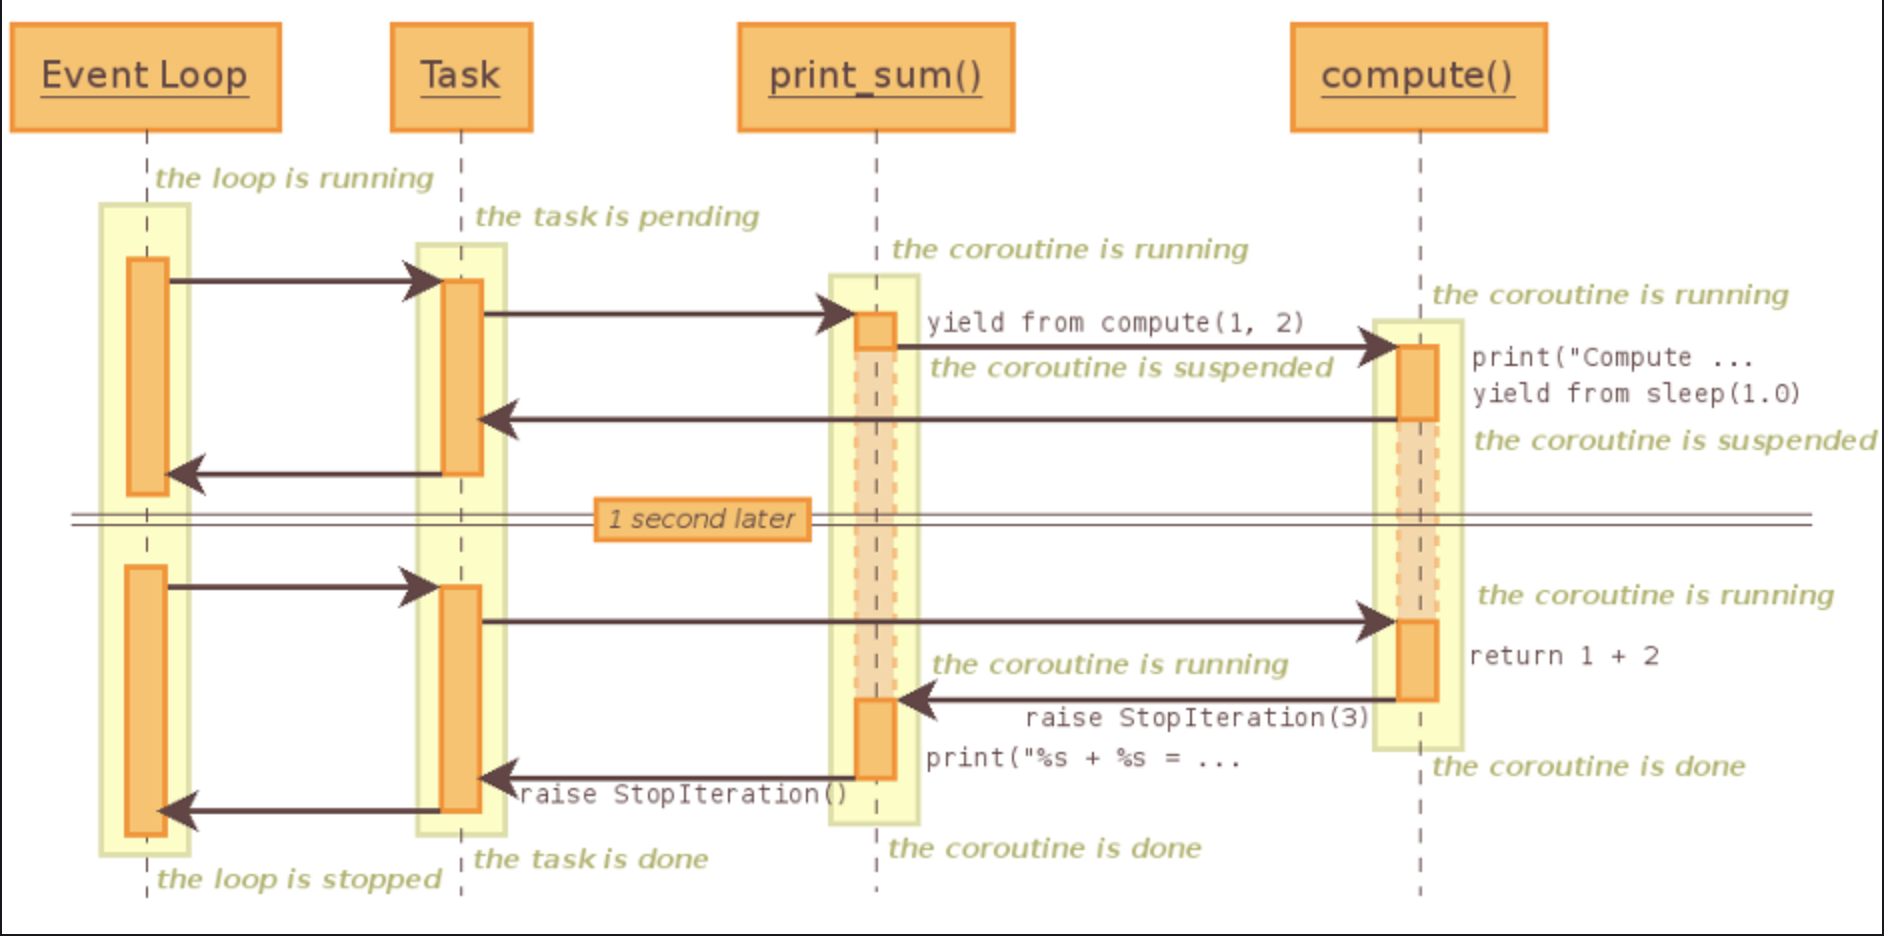

У Event Loop есть следующие сущности:

1. Очередь готовых callbacks/тасок — то, что надо выполнить прямо сейчас.(deque)
2. Очередь таймеров (delayed calls) — это приоритетная очередь по времени исполнения (heapq).
3. Регистрация I/O-событий — обёртка вокруг select()/epoll()/kqueue() через модуль selectors. (from select import select)
4. Signal handlers / callbacks из других потоков — тоже в итоге сводятся к push в очередь готовых callback’ов. 
(loop.call_soon_threadsafe(cb, *args))

### Современный asyncio

In [ ]:
async def main() -> None:
    print("Hello ...")
    await asyncio.sleep(1)
    print("... World!")

In [ ]:
await main()

#### Шедулинг корутин

In [ ]:
async def say_after(delay: int, what: str) -> None:
    print(f"wait for {delay}s")
    await asyncio.sleep(delay)
    print(what)

In [ ]:
import time

print(f"started at {time.strftime('%X')}")

await say_after(1, "hello")
await say_after(2, "world")

print(f"finished at {time.strftime('%X')}")

In [ ]:
task1 = asyncio.create_task(say_after(2, "hello"))
task2 = asyncio.create_task(say_after(1, "world"))

print(f"started at {time.strftime('%X')}")
print(f"finished at {time.strftime('%X')}")

Задачи (tasks) используются, чтобы запланировать (schedule) корутины на выполнение "параллельно" (конкурентно) 

Когда из корутины создают задачу через asyncio.create_task(), она автоматически запускается на следующем такте event loop'а (run soon)

#### asyncio.gather

In [ ]:
async def factorial(name: str, number: int) -> None:
    result = 1
    for i in range(2, number + 1):
        print(f"Task {name}: Compute factorial({i})...")
        await asyncio.sleep(1)
        result *= i
    print(f"Task {name}: factorial({number}) = {result}")
    return result

In [ ]:
await asyncio.gather(
    factorial("A", 2),
    factorial("B", 3),
    factorial("C", 4),
)

In [ ]:
async def factorial(name: str, number: int) -> None:
    result = 1
    for i in range(2, number + 1):
        if number % 2 and i == 2:
            raise RuntimeError("Whoops!")
        print(f"Task {name}: Compute factorial({i})...")
        await asyncio.sleep(1)
        result *= i
    print(f"Task {name}: factorial({number}) = {result}")
    return result


await asyncio.gather(
    factorial("A", 2),
    factorial("B", 3),
    factorial("C", 4),
    return_exceptions=True,
)